In [8]:
!pip install -q visualkeras
import visualkeras

In [9]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 0 = all logs, 1 = info, 2 = warning, 3 = error

In [10]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [11]:
!unzip "/content/drive/MyDrive/Retinal-Disease-main.zip" -d /content/


Archive:  /content/drive/MyDrive/Retinal-Disease-main.zip
   creating: /content/Retinal-Disease-main/
  inflating: /content/Retinal-Disease-main/app.py  
   creating: /content/Retinal-Disease-main/dataset/
   creating: /content/Retinal-Disease-main/dataset/cataract/
  inflating: /content/Retinal-Disease-main/dataset/cataract/0_left.jpg  
  inflating: /content/Retinal-Disease-main/dataset/cataract/103_left.jpg  
  inflating: /content/Retinal-Disease-main/dataset/cataract/1062_right.jpg  
  inflating: /content/Retinal-Disease-main/dataset/cataract/1083_left.jpg  
  inflating: /content/Retinal-Disease-main/dataset/cataract/1084_right.jpg  
  inflating: /content/Retinal-Disease-main/dataset/cataract/1102_left.jpg  
  inflating: /content/Retinal-Disease-main/dataset/cataract/1102_right.jpg  
  inflating: /content/Retinal-Disease-main/dataset/cataract/1115_left.jpg  
  inflating: /content/Retinal-Disease-main/dataset/cataract/1126_right.jpg  
  inflating: /content/Retinal-Disease-main/datase

In [12]:
# system libs
import os
import time
import shutil
import pathlib
import itertools

import random
import pandas as pd
import numpy as np

# visuals
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

# Ignore the warnings
import warnings
warnings.filterwarnings('always')
warnings.filterwarnings('ignore')

print ('LIBS ARE IMPORTED')

LIBS ARE IMPORTED


In [13]:
# Evaluation Lib.
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import label_binarize

In [14]:
import tensorflow as tf
print("Tensorflow version ",tf.__version__)

Tensorflow version  2.18.0


In [15]:
dataset_dir = '/content/Retinal-Disease-main/dataset'
class_names = sorted(os.listdir(dataset_dir))

num_class = len(class_names)

print(f"Class Names:{class_names}")
print(f"Number of Classes: {num_class}")

Class Names:['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']
Number of Classes: 4


In [16]:
from PIL import Image

im = Image.open('/content/Retinal-Disease-main/dataset/cataract/0_left.jpg')
width, height = im.size

print(f"width: {width}, height: {height}")

width: 512, height: 512


In [17]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset='training',
    batch_size=32,
    image_size=(256, 256),
    seed=123,
    shuffle=True,
)

# Load validation dataset without preprocessing
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset='validation',
    batch_size=32,
    image_size=(256, 256),
    seed=42,
)

Found 4217 files belonging to 4 classes.
Using 3374 files for training.
Found 4217 files belonging to 4 classes.
Using 843 files for validation.


In [18]:
def learn_label_counts(dataset,class_names):
    train_labels = np.concatenate([y for x,y in dataset], axis=0)
    values = pd.value_counts(train_labels)
    values = values.sort_index()

    print("Label Distribution:")
    for idx,count in values.items():
        print(f"{class_names[idx]} ({idx}): {count}")

    print("=="*50)
    data_iterator = dataset.as_numpy_iterator()
    batch = data_iterator.next()
    print("Batch Shape:",batch[0].shape)

    print("=="*50)
    plt.figure(figsize=(12,8))
    plt.pie(values,autopct='%1.1f%%', explode = [0.02,0.02,0.02, 0.02], textprops = {"fontsize":15})
    plt.legend(labels=class_names)
    plt.show()

Label Distribution:
cataract (0): 836
diabetic_retinopathy (1): 884
glaucoma (2): 802
normal (3): 852
Batch Shape: (32, 256, 256, 3)


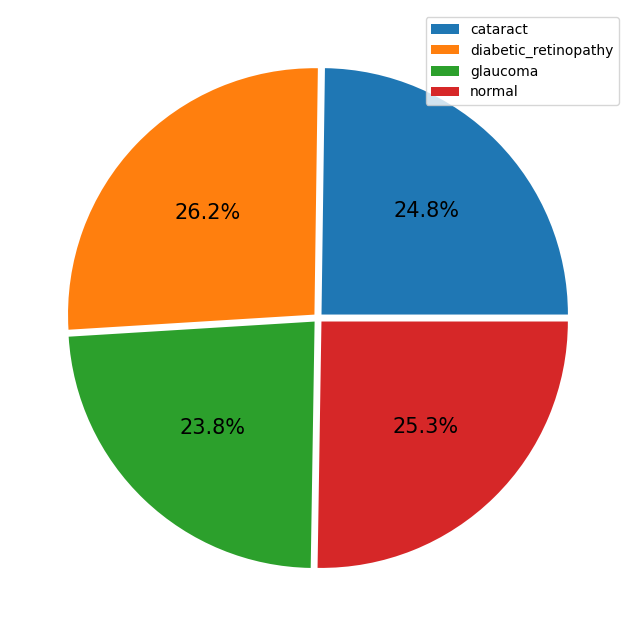

In [19]:
learn_label_counts(train_ds,class_names)

Label Distribution:
cataract (0): 204
diabetic_retinopathy (1): 217
glaucoma (2): 201
normal (3): 221
Batch Shape: (32, 256, 256, 3)


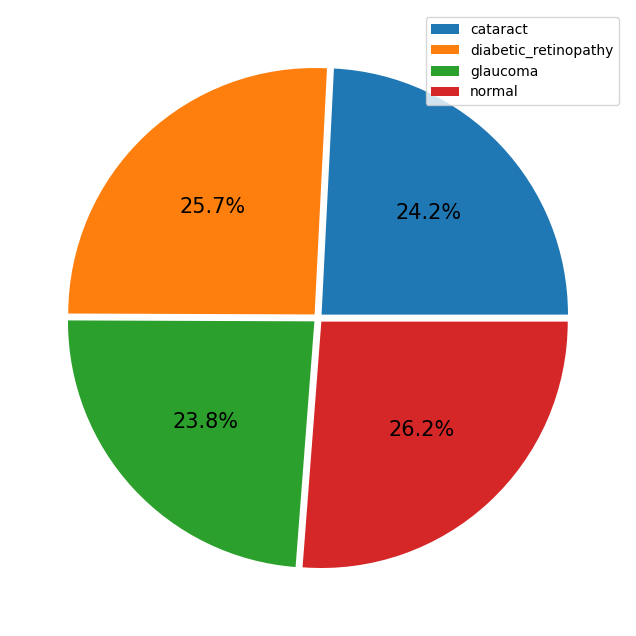

In [20]:
learn_label_counts(val_ds,class_names)

In [21]:
print("Shape of the first image in the training dataset:", next(iter(train_ds))[0][0].shape)
print("Shape of the first image in the validation dataset:", next(iter(val_ds))[0][0].shape)

Shape of the first image in the training dataset: (256, 256, 3)
Shape of the first image in the validation dataset: (256, 256, 3)


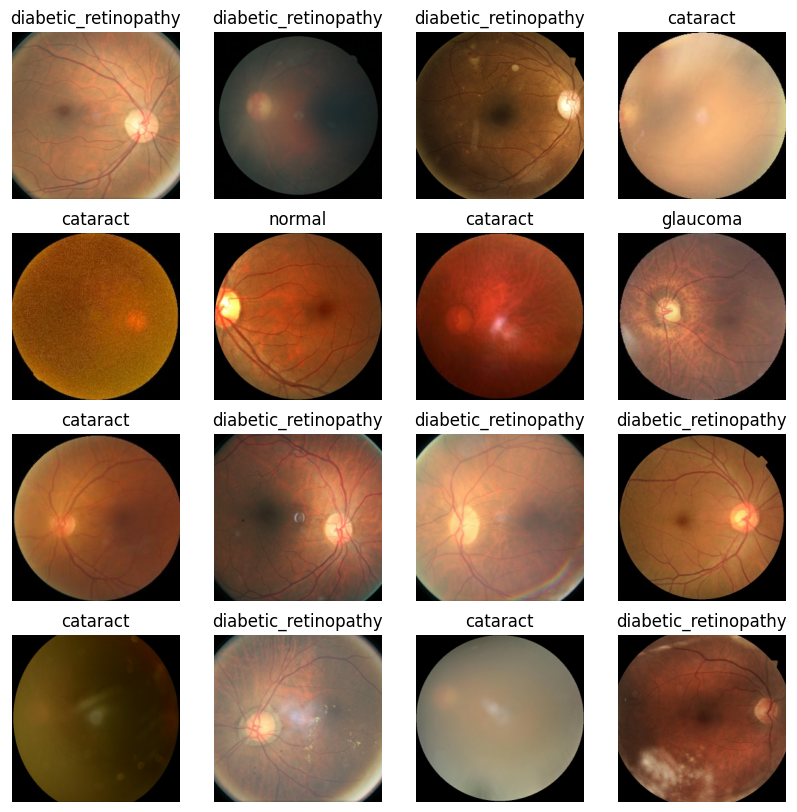

In [22]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [23]:
def visualize_images(path, target_size=(256, 256), num_images=5):
    """
    Visualize random images from a given directory.

    Args:
        path (str): Directory containing images.
        target_size (tuple): Desired image size for visualization.
        num_images (int): Number of images to display.

    Raises:
        ValueError: If no valid image files are found in the directory.
    """
    # Only allow common image formats
    valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
    image_filenames = [f for f in os.listdir(path)
                       if f.lower().endswith(valid_extensions) and os.path.isfile(os.path.join(path, f))]

    if not image_filenames:
        raise ValueError("No images found in the specified path")

    print("=="*50)
    print(path.split('/')[-1].upper())
    print("--"*50)

    # Randomly select images
    selected_images = random.sample(image_filenames, min(num_images, len(image_filenames)))

    # Create subplots
    fig, axes = plt.subplots(1, len(selected_images), figsize=(15, 3), facecolor='white')

    # Handle case when only one image (axes is not iterable)
    if len(selected_images) == 1:
        axes = [axes]

    for i, image_filename in enumerate(selected_images):
        try:
            # Load and resize image
            image_path = os.path.join(path, image_filename)
            image = Image.open(image_path).convert("RGB")  # ensure RGB mode
            image = image.resize(target_size)

            # Display image
            axes[i].imshow(image)
            axes[i].axis('off')
            axes[i].set_title(image_filename, fontsize=8)
        except Exception as e:
            axes[i].axis('off')
            axes[i].set_title("Error", fontsize=8)
            print(f"Error loading {image_filename}: {e}")

    plt.tight_layout()
    plt.show()

    print("=="*50)

CATARACT
----------------------------------------------------------------------------------------------------


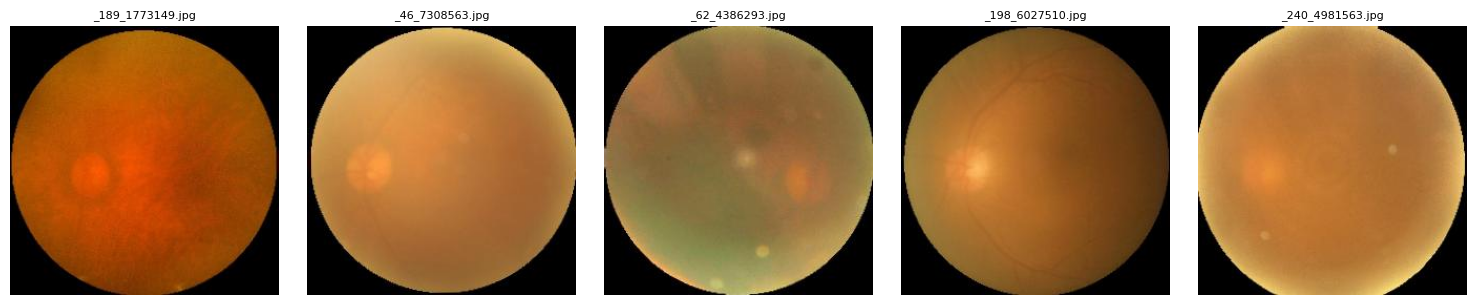

In [24]:
path_to_visualize = "/content/Retinal-Disease-main/dataset/cataract"
visualize_images(path_to_visualize, num_images=5)

DIABETIC_RETINOPATHY
----------------------------------------------------------------------------------------------------


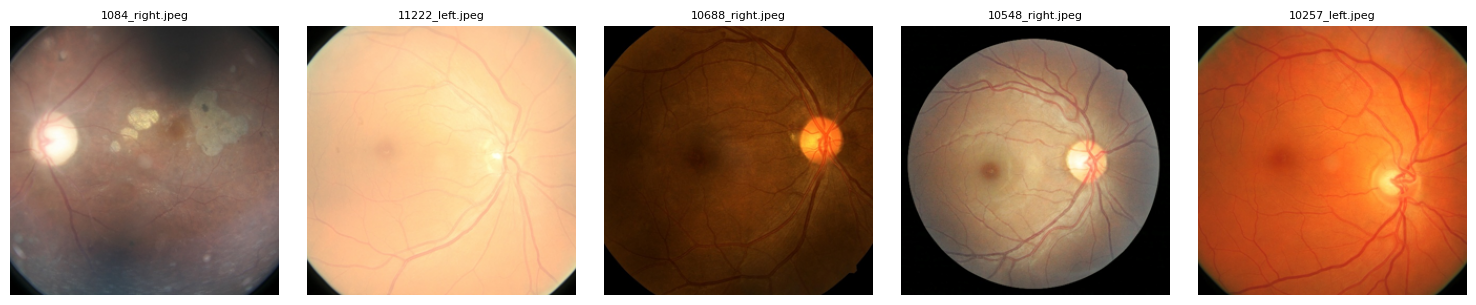

In [25]:
path_to_visualize = "/content/Retinal-Disease-main/dataset/diabetic_retinopathy"
visualize_images(path_to_visualize, num_images=5)

GLAUCOMA
----------------------------------------------------------------------------------------------------


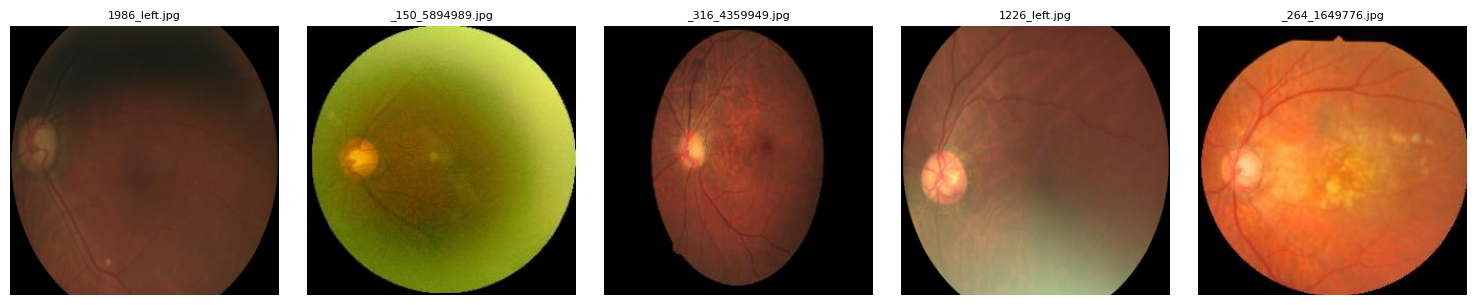

In [26]:
path_to_visualize = "/content/Retinal-Disease-main/dataset/glaucoma"
visualize_images(path_to_visualize, num_images=5)

NORMAL
----------------------------------------------------------------------------------------------------


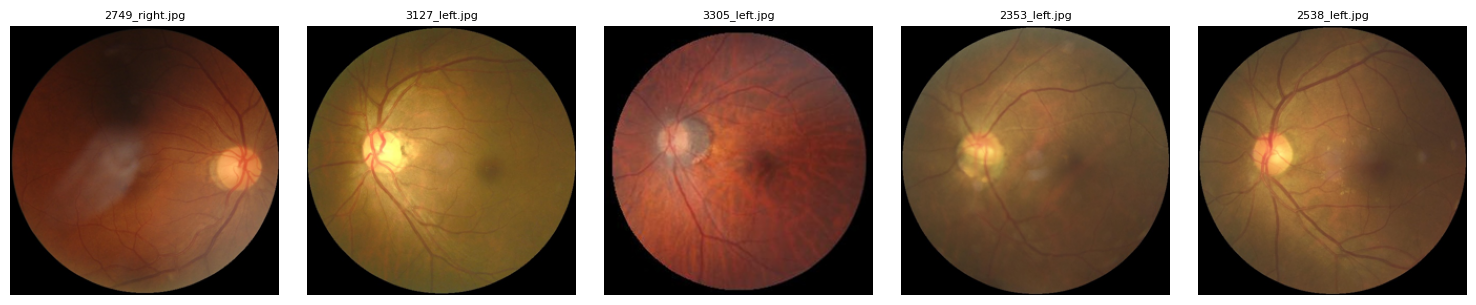

In [27]:
path_to_visualize = "/content/Retinal-Disease-main/dataset/normal"
visualize_images(path_to_visualize, num_images=5)

In [28]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [29]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),  # Flip image horizontally (suitable for symmetric organs like eyes)
    tf.keras.layers.RandomRotation(0.1),       # Small rotation (0.1 ~ ±10%) to avoid unrealistic deformation
    tf.keras.layers.RandomZoom(0.1),           # Slight zoom in/out
    tf.keras.layers.RandomContrast(0.1),       # Vary contrast to simulate lighting differences
    tf.keras.layers.RandomBrightness(0.1),     # Simulate different brightness levels
    tf.keras.layers.RandomTranslation(0.1, 0.1), # Slight translation (up/down, left/right)
    tf.keras.layers.GaussianNoise(0.05),       # Add random noise to simulate sensor noise
])

### Inception Model and Layer Additions

In [30]:
from tensorflow.keras.applications import InceptionV3

base_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(256, 256, 3))

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [31]:
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, layer.trainable)

0 input_layer True
1 conv2d True
2 batch_normalization True
3 activation True
4 conv2d_1 True
5 batch_normalization_1 True
6 activation_1 True
7 conv2d_2 True
8 batch_normalization_2 True
9 activation_2 True
10 max_pooling2d True
11 conv2d_3 True
12 batch_normalization_3 True
13 activation_3 True
14 conv2d_4 True
15 batch_normalization_4 True
16 activation_4 True
17 max_pooling2d_1 True
18 conv2d_8 True
19 batch_normalization_8 True
20 activation_8 True
21 conv2d_6 True
22 conv2d_9 True
23 batch_normalization_6 True
24 batch_normalization_9 True
25 activation_6 True
26 activation_9 True
27 average_pooling2d True
28 conv2d_5 True
29 conv2d_7 True
30 conv2d_10 True
31 conv2d_11 True
32 batch_normalization_5 True
33 batch_normalization_7 True
34 batch_normalization_10 True
35 batch_normalization_11 True
36 activation_5 True
37 activation_7 True
38 activation_10 True
39 activation_11 True
40 mixed0 True
41 conv2d_15 True
42 batch_normalization_15 True
43 activation_15 True
44 conv2d_13 Tru

In [32]:
from tensorflow.keras import Model
cut_layer = base_model.get_layer('mixed8')
truncated_model = Model(inputs=base_model.input, outputs=cut_layer.output)

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.applications.inception_v3 import preprocess_input

truncated_model.trainable = True

# --- Build model with Functional API
inputs = tf.keras.Input(shape=(256, 256, 3))
x = data_augmentation(inputs)              
x = preprocess_input(x)                  
x = truncated_model(x, training=True)     
x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

In [34]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 6, 6, 1280)     │    10,674,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_94 (Conv2D)              │ (None, 6, 6, 256)      │     2,949,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_95 (Conv2D)              │ (None, 6, 6, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_95          │ (None, 6, 6, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,987,236 (53.36 MB)

 Trainable params: 13,965,092 (53.27 MB)

 Non-trainable params: 22,144 (86.50 KB)

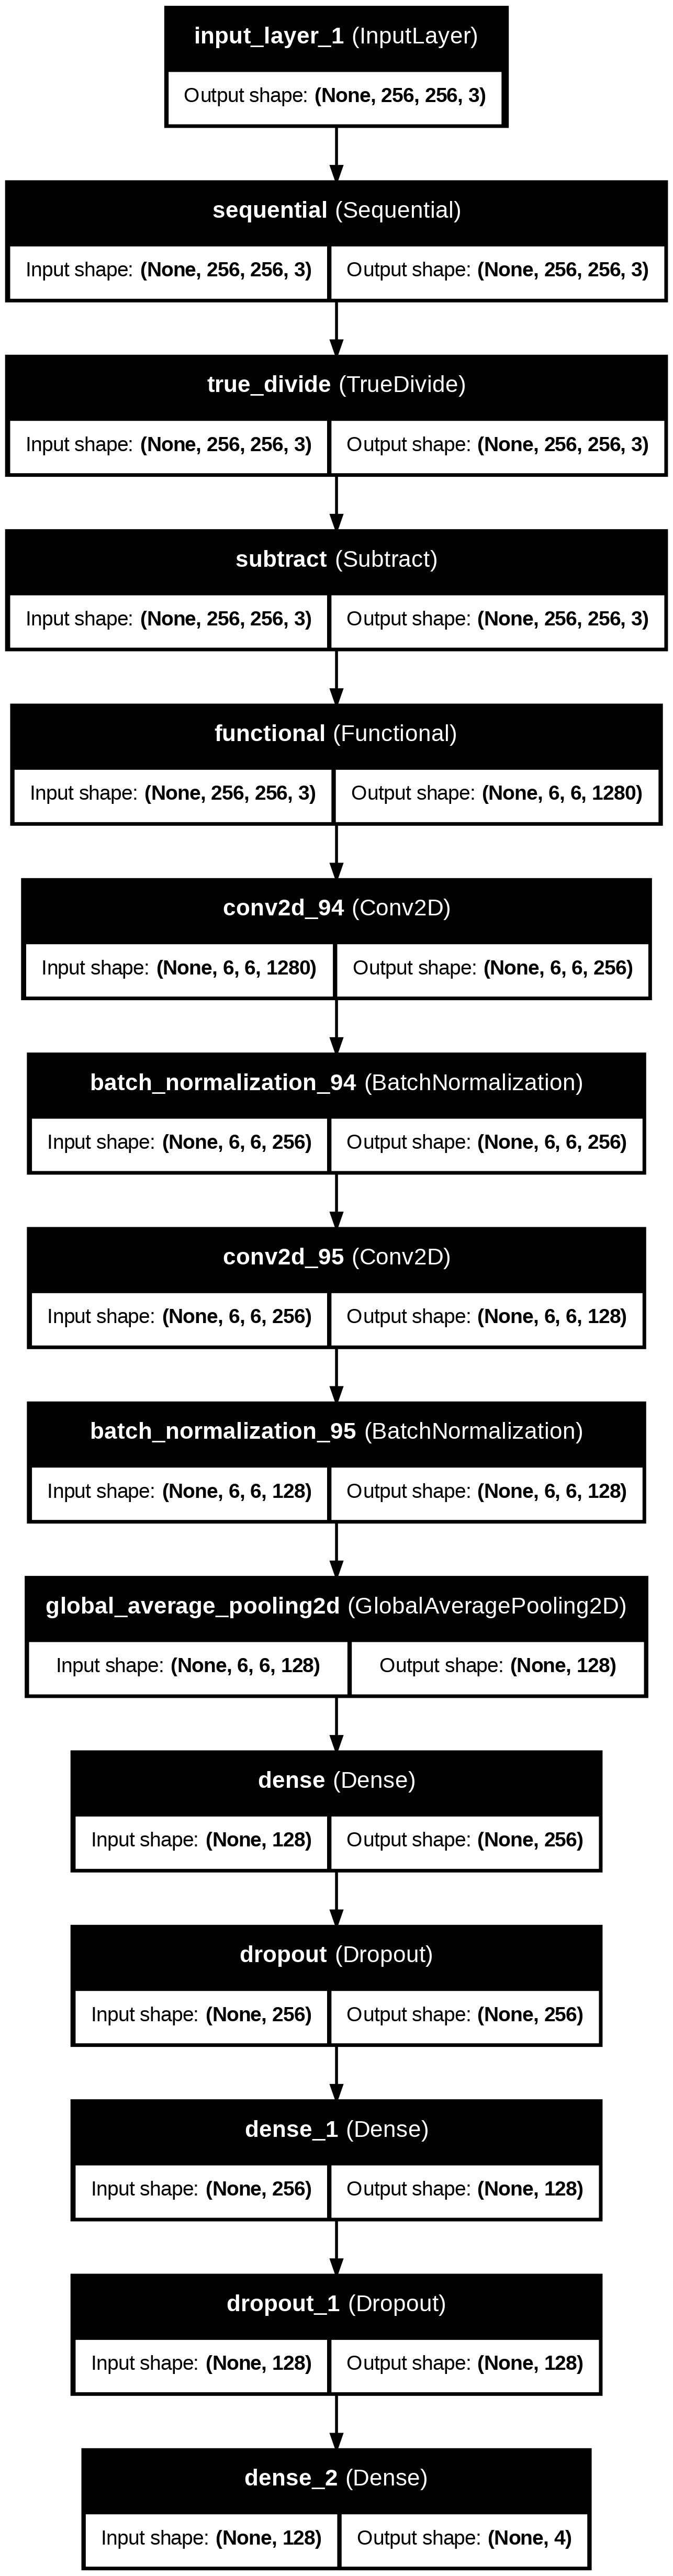

In [35]:
from keras.utils import plot_model
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

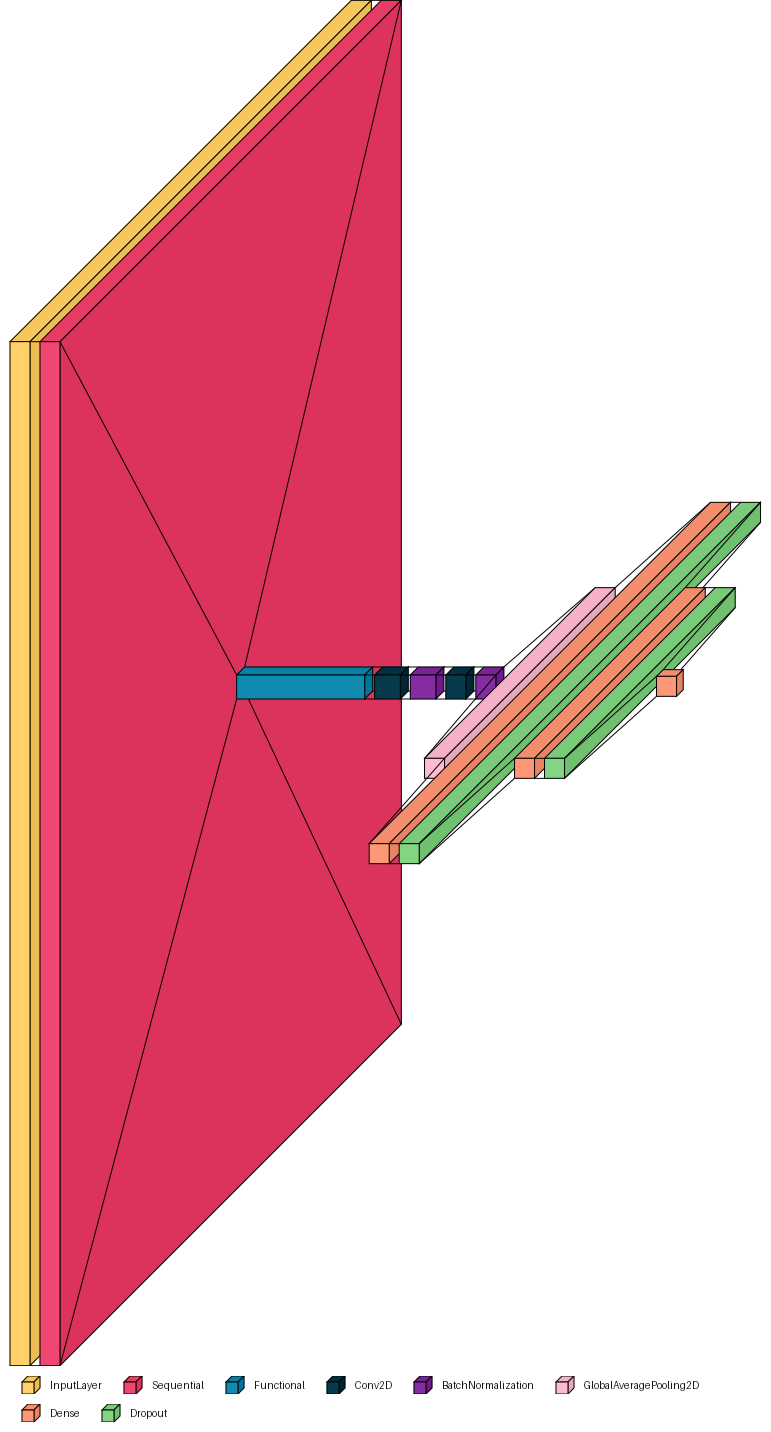

In [36]:
visualkeras.layered_view(model,legend=True,one_dim_orientation='x')

In [37]:
from sklearn.utils.class_weight import compute_class_weight

labels = np.concatenate([y.numpy() for x, y in train_ds], axis=0)
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weight_dict = dict(zip(np.unique(labels), class_weights))
print(class_weight_dict)

{np.int32(0): np.float64(1.0089712918660287), np.int32(1): np.float64(0.954185520361991), np.int32(2): np.float64(1.0517456359102244), np.int32(3): np.float64(0.9900234741784038)}


In [38]:
# one hot encoding

In [39]:
train_ds = train_ds.map(lambda x, y: (x, tf.one_hot(y, depth=4)))
val_ds = val_ds.map(lambda x, y: (x, tf.one_hot(y, depth=4)))

In [40]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.F1Score(average='macro', name='f1_score')
    ]
)

In [41]:
# Callbacks
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau,
    TensorBoard, LearningRateScheduler
)

def lr_schedule(epoch):
    initial_lr = 0.001
    drop_factor = 0.5
    drop_every = 5
    lr = initial_lr * (drop_factor ** (epoch // drop_every))
    return lr


model_checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1,
    mode='max',  # 'max' for accuracy, 'min' for loss
    save_freq='epoch',
    save_weights_only=False
)


early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=50,
    mode='max',
    verbose=1,
    restore_best_weights=True,
    baseline=0.99,
    min_delta=0.001
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    mode='min',
    min_delta=0.001,
    cooldown=2,
    min_lr=1e-6,
    epsilon=0.001
)

lr_scheduler = LearningRateScheduler(lr_schedule)

In [42]:
history = model.fit(
    train_ds,
    epochs=100,
    validation_data=val_ds,
    callbacks=[early_stopping,model_checkpoint,lr_scheduler],
    verbose=1,
    class_weight = class_weight_dict
)

Epoch 1/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.6052 - auc: 0.8295 - f1_score: 0.6044 - loss: 0.9825 - precision: 0.7269 - recall: 0.4575
Epoch 1: val_accuracy improved from -inf to 0.25623, saving model to best_model.keras
106/106 ━━━━━━━━━━━━━━━━━━━━ 101s 493ms/step - accuracy: 0.6058 - auc: 0.8299 - f1_score: 0.6051 - loss: 0.9813 - precision: 0.7272 - recall: 0.4586 - val_accuracy: 0.2562 - val_auc: 0.4775 - val_f1_score: 0.1085 - val_loss: 8.5811 - val_precision: 0.2548 - val_recall: 0.2527 - learning_rate: 0.0010
Epoch 2/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.7816 - auc: 0.9357 - f1_score: 0.7821 - loss: 0.6166 - precision: 0.8215 - recall: 0.7280
Epoch 2: val_accuracy improved from 0.25623 to 0.62396, saving model to best_model.keras
106/106 ━━━━━━━━━━━━━━━━━━━━ 46s 433ms/step - accuracy: 0.7817 - auc: 0.9357 - f1_score: 0.7822 - loss: 0.6166 - precision: 0.8216 - recall: 0.7281 - val_accuracy: 0.6240 - val_auc: 0.8411 - val_f1_score: 0

In [43]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
print("Training Accuracy:", train_accuracy[-1])
print("Validation Accuracy:", val_accuracy[-1])

Training Accuracy: 0.9854771494865417
Validation Accuracy: 0.9217081665992737


In [44]:
history_dict = history.history

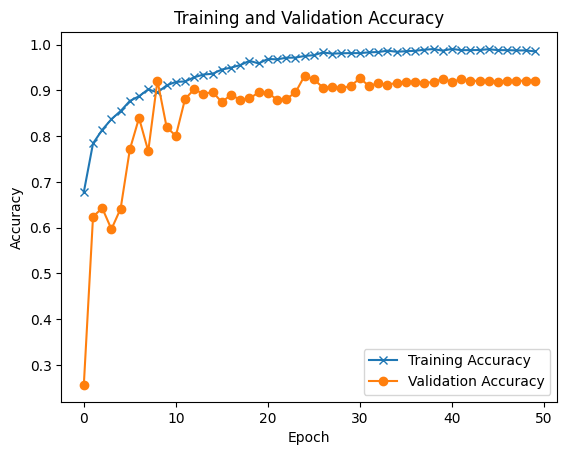

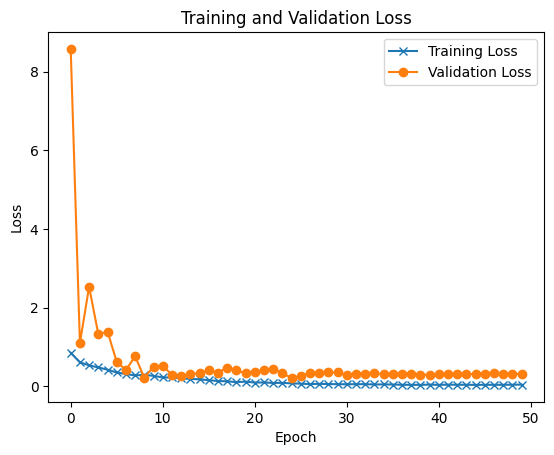

In [45]:
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='x')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy',marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()
# Plot training history
plt.plot(history.history['loss'], label='Training Loss',marker='x')
plt.plot(history.history['val_loss'], label='Validation Loss',marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

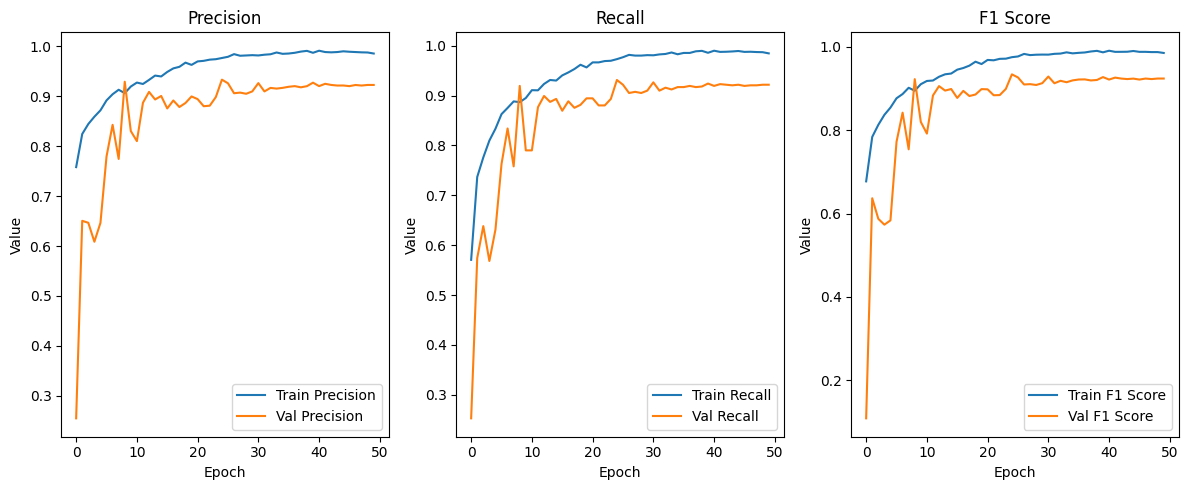

In [46]:
# Precision, Recall, F1 Score
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.plot(history_dict['precision'], label='Train Precision')
plt.plot(history_dict['val_precision'], label='Val Precision')
plt.title("Precision")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_dict['recall'], label='Train Recall')
plt.plot(history_dict['val_recall'], label='Val Recall')
plt.title("Recall")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history_dict['f1_score'], label='Train F1 Score')
plt.plot(history_dict['val_f1_score'], label='Val F1 Score')
plt.title("F1 Score")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()

plt.tight_layout()
plt.show()

In [47]:
from tensorflow.keras.models import load_model
model = load_model('best_model.keras')

In [48]:
results = model.evaluate(val_ds, return_dict=True)

for metric, value in results.items():
    print(f"{metric}: {value:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.9286 - auc: 0.9915 - f1_score: 0.9300 - loss: 0.2076 - precision: 0.9304 - recall: 0.9271
accuracy: 0.9324
auc: 0.9908
f1_score: 0.9340
loss: 0.2131
precision: 0.9334
recall: 0.9312


In [49]:
from sklearn.metrics import roc_curve, auc

y_true = []
y_pred = []

for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch)
    preds = np.argmax(preds, axis=1)


    y_true_batch = np.argmax(y_batch.numpy(), axis=1) if y_batch.numpy().ndim > 1 else y_batch.numpy()

    y_true.extend(y_true_batch)
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

In [50]:
print(y_pred)

[1 2 0 0 3 0 1 3 0 3 0 3 2 1 1 1 2 0 2 1 3 2 3 3 3 1 1 2 3 0 2 3 0 3 0 1 3
 0 1 2 2 2 0 0 3 0 2 3 0 3 1 3 0 3 2 3 0 0 3 3 3 1 3 3 2 1 0 3 3 3 2 0 3 3
 0 2 3 3 2 1 2 0 3 0 3 3 3 2 1 3 2 3 2 2 0 1 2 3 3 3 3 0 1 0 1 3 2 1 1 0 1
 1 2 1 2 0 0 2 1 3 2 2 0 1 3 2 1 3 0 0 0 3 1 3 0 1 1 3 0 1 1 0 0 1 3 2 3 0
 1 0 2 1 2 1 2 1 2 3 1 1 2 0 2 1 1 1 0 3 0 1 0 2 2 1 0 3 0 2 3 0 2 2 3 2 0
 2 3 1 1 3 0 2 0 3 1 2 1 0 1 2 2 2 0 3 1 1 1 1 2 0 2 2 2 1 3 3 1 3 0 3 2 3
 1 3 1 2 1 2 1 0 0 2 2 3 2 1 1 1 3 1 2 2 1 0 3 3 2 2 0 2 1 3 2 3 1 2 1 2 2
 0 3 2 2 2 0 3 3 3 0 0 1 0 0 2 0 3 3 1 2 1 1 3 1 2 3 0 0 1 2 2 0 3 2 2 0 1
 2 1 3 0 1 3 3 2 0 3 1 3 0 2 2 0 0 3 0 3 2 0 1 1 2 0 0 1 0 2 1 1 2 3 3 0 3
 1 2 2 1 0 1 2 3 0 0 3 3 2 3 1 0 1 0 3 2 2 3 0 3 2 3 0 0 1 1 2 3 1 1 1 3 0
 3 1 1 2 1 2 1 2 2 3 0 0 2 1 2 2 2 1 3 3 0 2 2 2 3 1 3 3 0 0 3 2 2 3 3 3 3
 0 1 0 3 1 3 1 1 2 3 3 1 0 3 2 0 0 2 2 0 3 1 3 0 0 1 2 0 1 3 3 1 1 3 3 1 0
 3 3 0 2 2 0 3 3 3 0 1 0 0 3 3 1 3 0 1 0 3 3 2 1 2 1 2 0 2 0 2 2 0 1 0 1 1
 3 3 3 0 2 1 0 0 3 2 1 0 

In [51]:
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[196   0   3   5]
 [  0 194   1  22]
 [  2   0 189  10]
 [  0   2  12 207]]


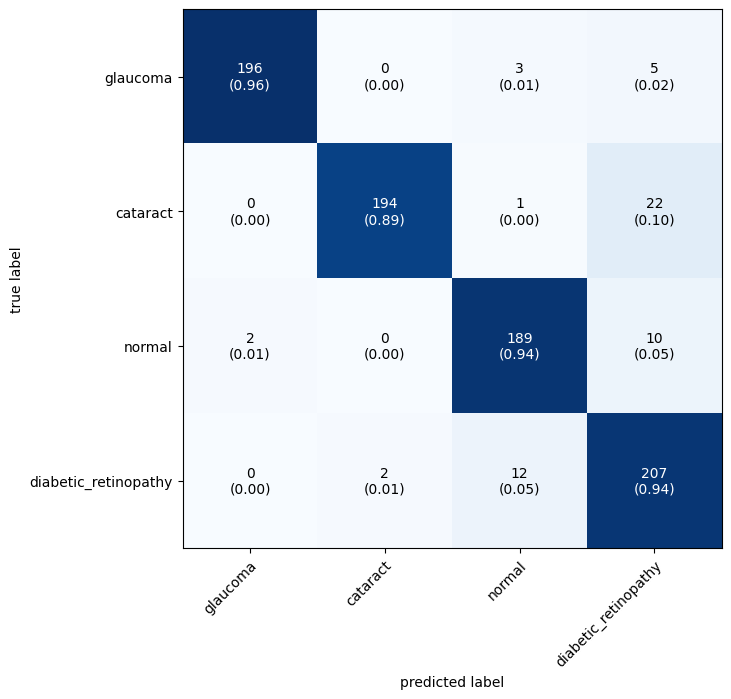

In [52]:
from mlxtend.plotting import plot_confusion_matrix
plot_confusion_matrix(conf_mat = cm,figsize=(8,7),class_names = ["glaucoma", "cataract", "normal", "diabetic_retinopathy"],
                      show_normed = True);
plt.savefig("Predected & True Label.png")

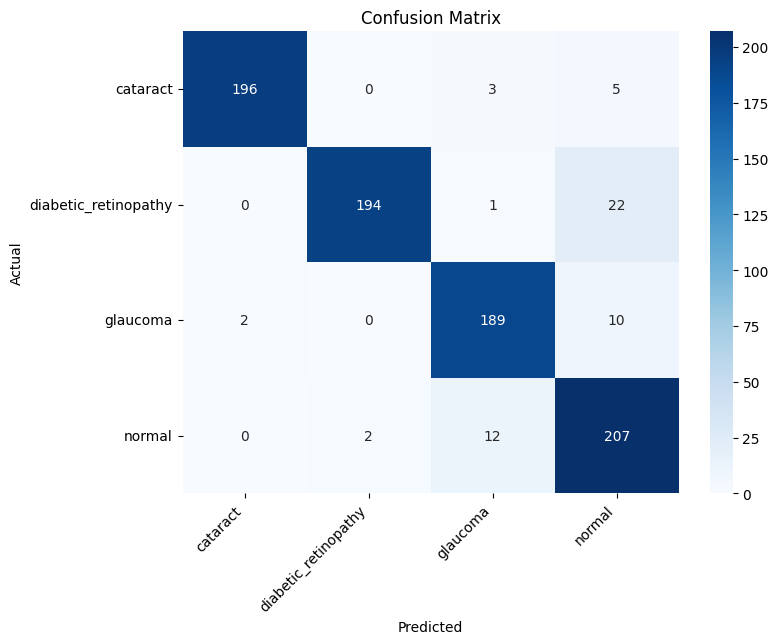

In [53]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Actual')
plt.yticks(rotation=0, ha='right')
plt.title('Confusion Matrix')
plt.show()

In [54]:
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", report)

Classification Report:
                       precision    recall  f1-score   support

            cataract       0.99      0.96      0.98       204
diabetic_retinopathy       0.99      0.89      0.94       217
            glaucoma       0.92      0.94      0.93       201
              normal       0.85      0.94      0.89       221

            accuracy                           0.93       843
           macro avg       0.94      0.93      0.93       843
        weighted avg       0.94      0.93      0.93       843



In [55]:
y_pred_prob = model.predict(val_ds)

27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 154ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

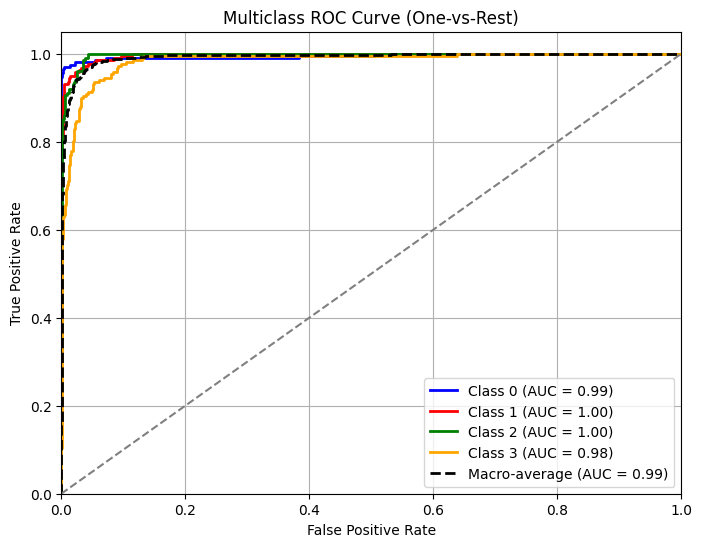

In [59]:
y_true = []
y_pred_proba = []

for x_batch, y_batch in val_ds:
    probs = model.predict(x_batch)  #(softmax)
    y_true_batch = np.argmax(y_batch.numpy(), axis=1) if y_batch.numpy().ndim > 1 else y_batch.numpy()

    y_true.extend(y_true_batch)
    y_pred_proba.extend(probs)

y_true = np.array(y_true)
y_pred_proba = np.array(y_pred_proba)

n_classes = y_pred_proba.shape[1]


y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))


fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["macro"], tpr["macro"], _ = roc_curve(y_true_bin.ravel(), y_pred_proba.ravel())
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange', 'purple']
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i % len(colors)], lw=2,
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')


plt.plot(fpr["macro"], tpr["macro"], color='black', linestyle='--', lw=2,
         label=f'Macro-average (AUC = {roc_auc["macro"]:.2f})')


plt.plot([0, 1], [0, 1], color='gray', linestyle='--')


plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [60]:
def predict(model, img):
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


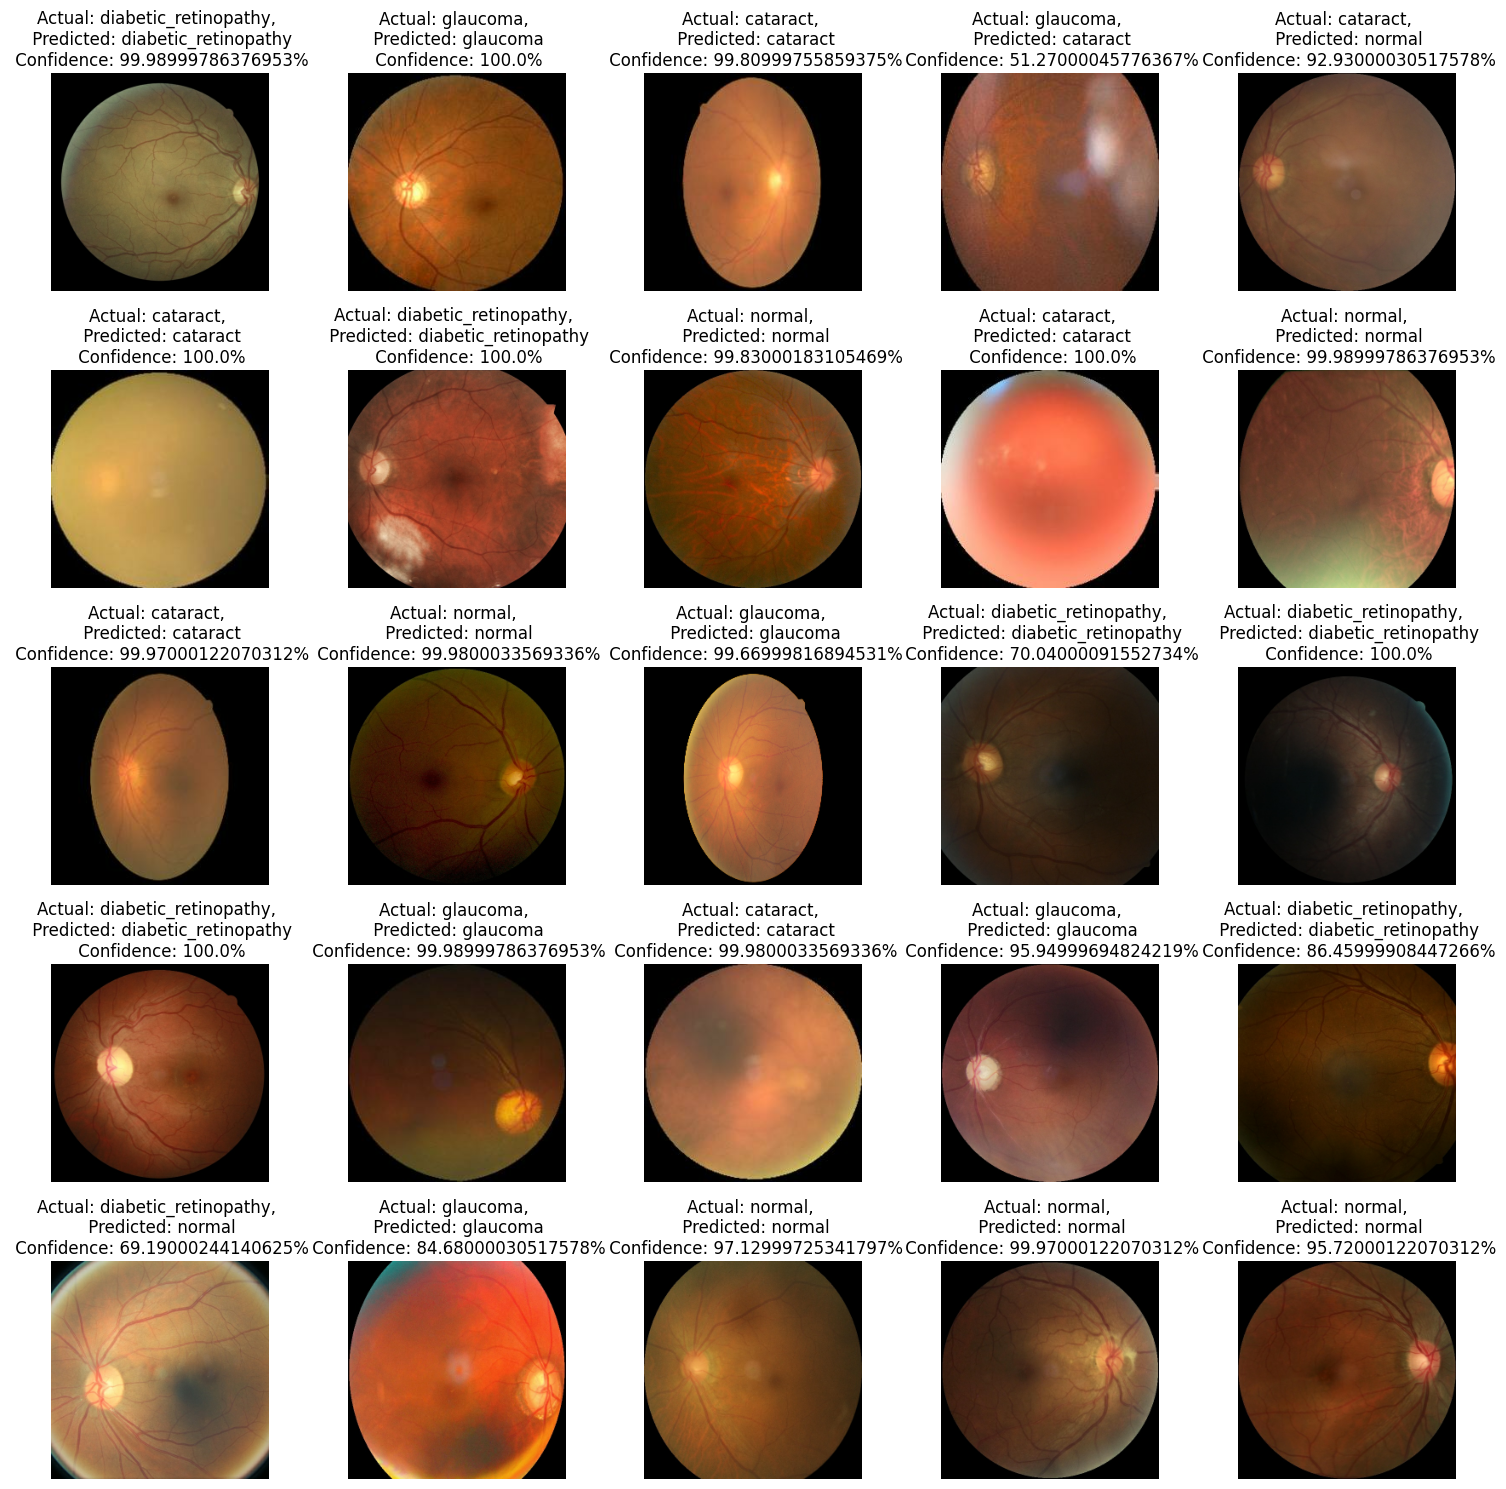

In [61]:
plt.figure(figsize=(15, 15))
for images, labels in val_ds.take(1):
    for i in range(25):
        ax = plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(model, images[i].numpy())

        actual_class = class_names[labels[i].numpy()] if labels[i].numpy().ndim == 0 else class_names[np.argmax(labels[i].numpy())]

        plt.title(f"Actual: {actual_class}, \n Predicted: {predicted_class}\n Confidence: {confidence}%")
        plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted class: Diabetic Retinopathy (68.24%)


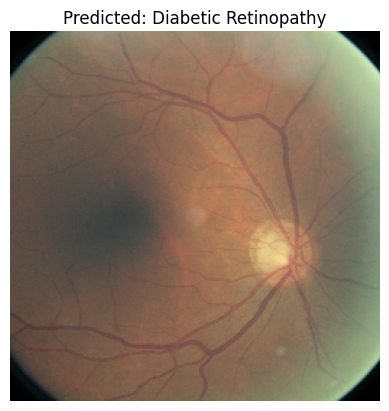

In [66]:
from tensorflow.keras.preprocessing import image

class_names = ['Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Normal']

img_path = '/content/Retinal-Disease-main/dataset/diabetic_retinopathy/1000_left.jpeg'

img = tf.keras.utils.load_img(img_path, target_size=(256, 256))
img_array = tf.keras.utils.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0).astype(np.float32)

pred = model.predict(img_array)
predicted_class = np.argmax(pred[0])
confidence = np.max(pred[0])

print(f"Predicted class: {class_names[predicted_class]} ({confidence*100:.2f}%)")

plt.imshow(img)
plt.title(f"Predicted: {class_names[predicted_class]}")
plt.axis('off')
plt.show()

2501_right.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Predicted class: Normal (98.46%)


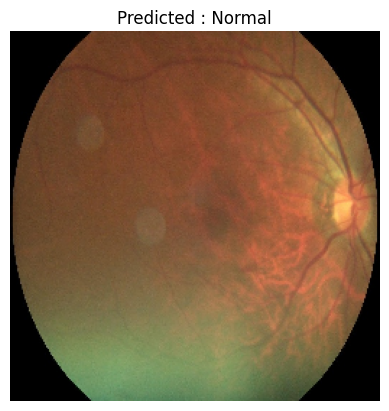

3406_right.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Predicted class: Normal (99.88%)


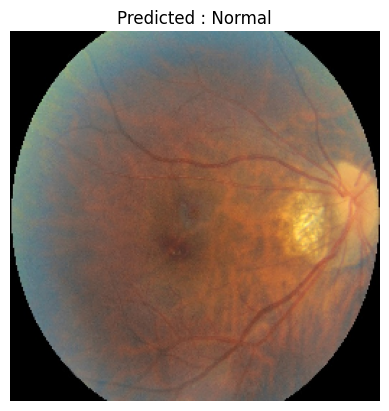

2354_right.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Predicted class: Normal (99.62%)


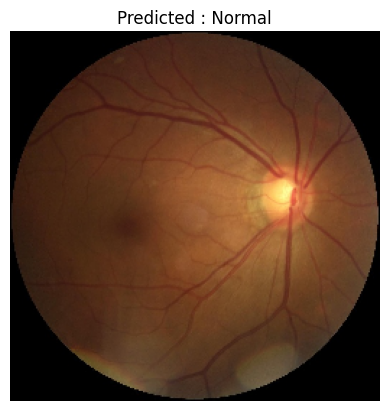

2813_left.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted class: Normal (99.95%)


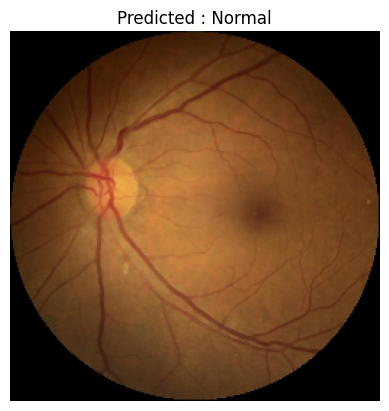

2782_left.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Predicted class: Normal (99.52%)


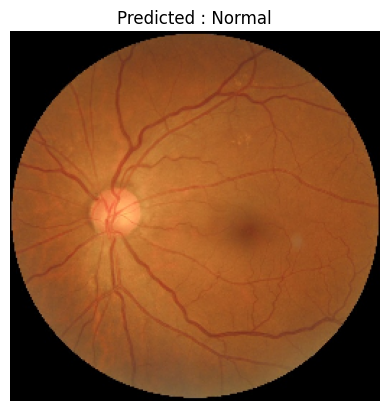

3365_left.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Predicted class: Glaucoma (79.11%)


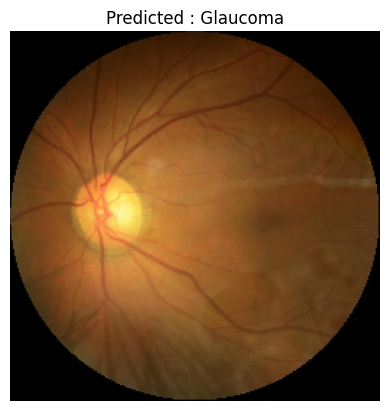

2657_left.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted class: Normal (99.21%)


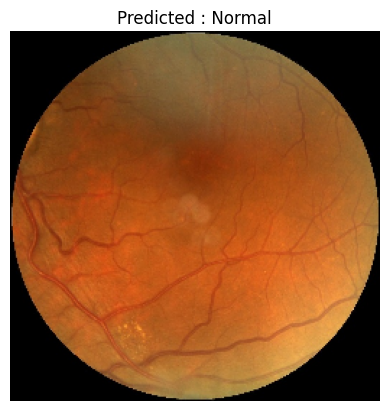

2355_left.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Predicted class: Normal (99.89%)


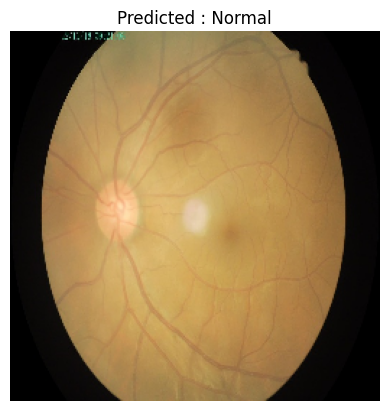

2353_right.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted class: Normal (99.92%)


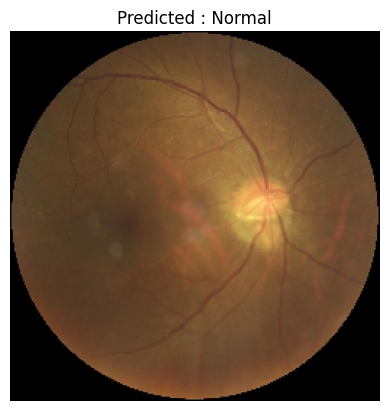

2645_right.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predicted class: Normal (96.54%)


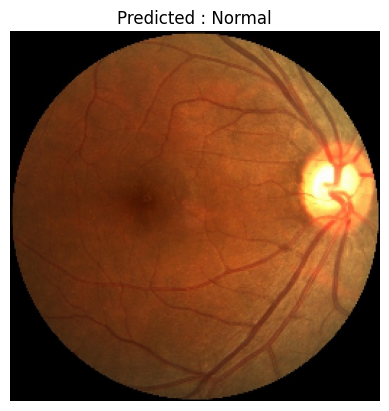

In [67]:
control_dir = "/content/Retinal-Disease-main/dataset/normal"

for name in os.listdir(control_dir)[:10]:
    print(name)
    class_names = ['Cataract', 'Diabetic Retinopathy', 'Glaucoma', 'Normal']

    img_path  = os.path.join(control_dir,name)

    img = tf.keras.utils.load_img(img_path, target_size=(256, 256))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0).astype(np.float32)

    pred = model.predict(img_array)
    predicted_class = np.argmax(pred[0])
    confidence = np.max(pred[0])

    print(f"Predicted class: {class_names[predicted_class]} ({confidence*100:.2f}%)")

    plt.imshow(img)
    plt.title(f"Predicted : {class_names[predicted_class]}")
    plt.axis('off')
    plt.show()
